In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("rice_bioactive_compounds.csv")

# Shape
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# First 5 rows
print("\nFirst 5 Rows:")
print(df.head())

# Statistical summary
print("\nSummary Statistics:")
print(df.describe())

Shape of dataset: (132, 21)

Columns:
Index(['S.No', 'Bioactive compound', 'Smiles', 'Class', 'Rice source ',
       'Properties (related to skin)', 'Mol.Weight(g/mol)', 'HBA', 'HBD',
       'QED', 'TPSA (A^2)', 'Fsp^3', 'Flexibility', 'LogS', 'LogP', 'LogD',
       'Pka', 'Skin sensitization', 'Melting point(°C)', 'Rotatable Bonds',
       'V cell(logkp)'],
      dtype='object')

Data Types:
S.No                              int64
Bioactive compound               object
Smiles                           object
Class                            object
Rice source                      object
Properties (related to skin)     object
Mol.Weight(g/mol)               float64
HBA                               int64
HBD                               int64
QED                             float64
TPSA (A^2)                      float64
Fsp^3                           float64
Flexibility                     float64
LogS                            float64
LogP                            float64
LogD

In [ ]:
# Check missing values
print(df.isnull().sum())

S.No                            0
Bioactive compound              0
Smiles                          0
Class                           0
Rice source                     0
Properties (related to skin)    0
Mol.Weight(g/mol)               0
HBA                             0
HBD                             0
QED                             0
TPSA (A^2)                      0
Fsp^3                           0
Flexibility                     0
LogS                            0
LogP                            0
LogD                            0
Pka                             1
Skin sensitization              0
Melting point(°C)               0
Rotatable Bonds                 0
V cell(logkp)                   0
dtype: int64


In [ ]:
# Check for '-' entries
print((df == '-').sum())

S.No                             0
Bioactive compound               0
Smiles                           0
Class                            0
Rice source                      0
Properties (related to skin)     0
Mol.Weight(g/mol)                0
HBA                              0
HBD                              0
QED                              0
TPSA (A^2)                       0
Fsp^3                            0
Flexibility                      0
LogS                             0
LogP                             0
LogD                             0
Pka                             83
Skin sensitization               0
Melting point(°C)               57
Rotatable Bonds                  0
V cell(logkp)                    0
dtype: int64


In [ ]:
import numpy as np

# Replace invalid entries with NaN
df.replace('-', np.nan, inplace=True)

In [ ]:
numeric_cols = [
    'Mol.Weight(g/mol)',
    'HBA',
    'HBD',
    'TPSA (A^2)',
    'LogP',
    'LogS',
    'Rotatable Bonds',
    'V cell(logkp)'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
print(df[numeric_cols].isnull().sum())

Mol.Weight(g/mol)    0
HBA                  0
HBD                  0
TPSA (A^2)           0
LogP                 0
LogS                 0
Rotatable Bonds      0
V cell(logkp)        0
dtype: int64


In [ ]:
df = df.dropna(subset=['V cell(logkp)'])

In [ ]:
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_12702/3154000584.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   S.No                          132 non-null    int64  
 1   Bioactive compound            132 non-null    object 
 2   Smiles                        132 non-null    object 
 3   Class                         132 non-null    object 
 4   Rice source                   132 non-null    object 
 5   Properties (related to skin)  132 non-null    object 
 6   Mol.Weight(g/mol)             132 non-null    float64
 7   HBA                           132 non-null    int64  
 8   HBD                           132 non-null    int64  
 9   QED                           132 non-null    float64
 10  TPSA (A^2)                    132 non-null    float64
 11  Fsp^3                         132 non-null    float64
 12  Flexibility                   132 non-null    float64
 13  LogS 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Better plot size
plt.rcParams['figure.figsize'] = (8,5)

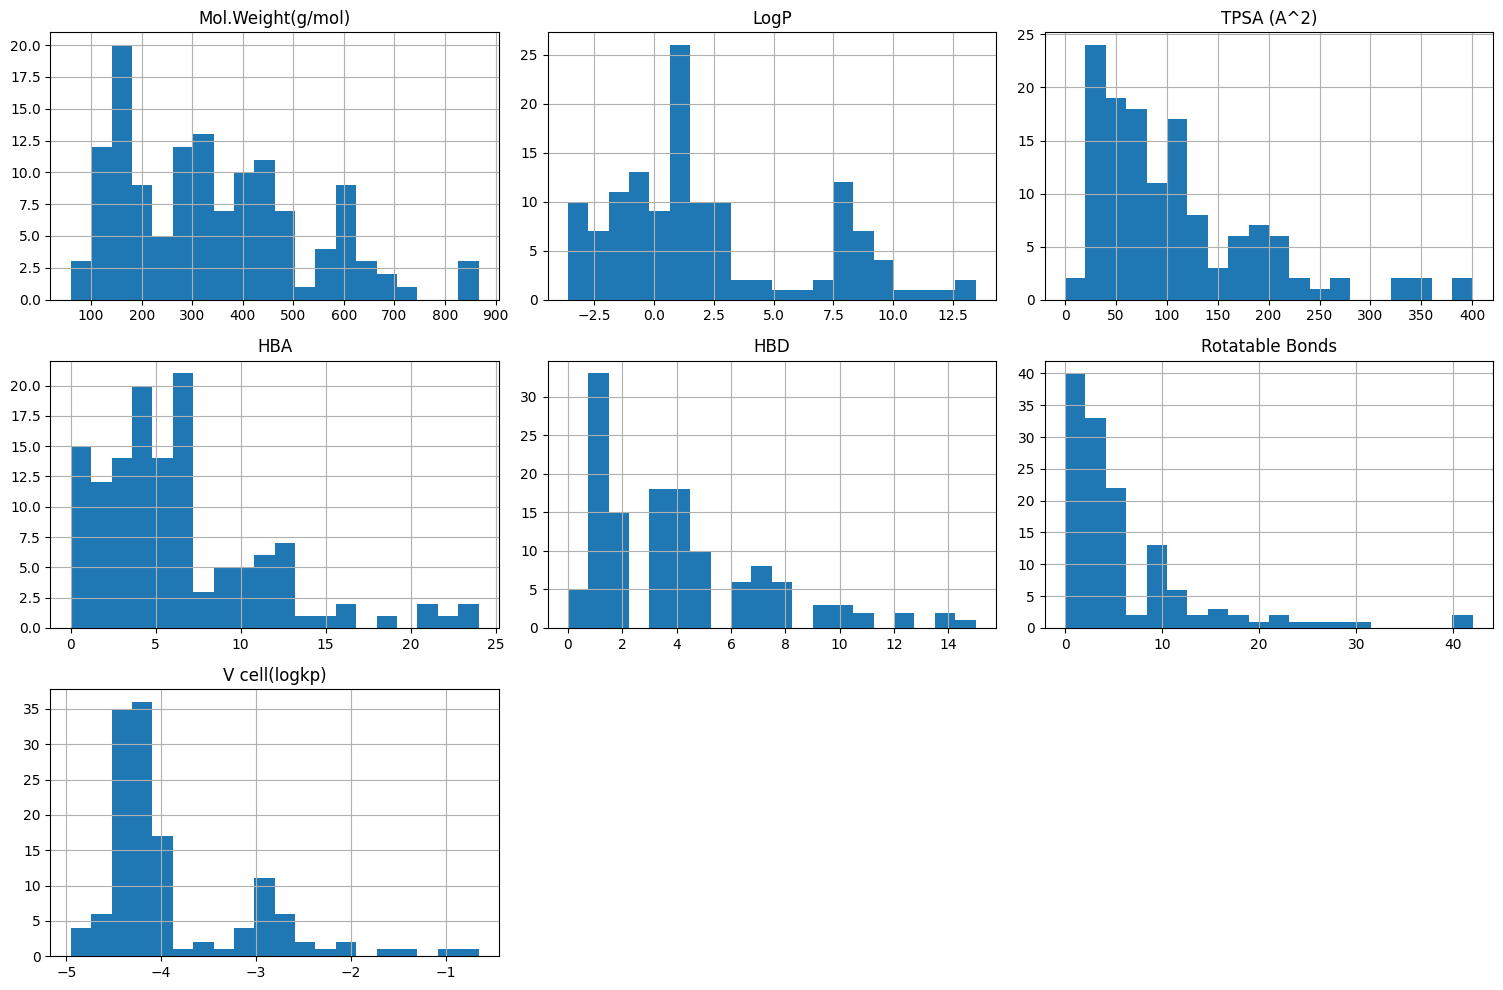

In [ ]:
features = [
    'Mol.Weight(g/mol)',
    'LogP',
    'TPSA (A^2)',
    'HBA',
    'HBD',
    'Rotatable Bonds',
    'V cell(logkp)'
]

df[features].hist(bins=20, figsize=(15,10))
plt.tight_layout()
plt.show()

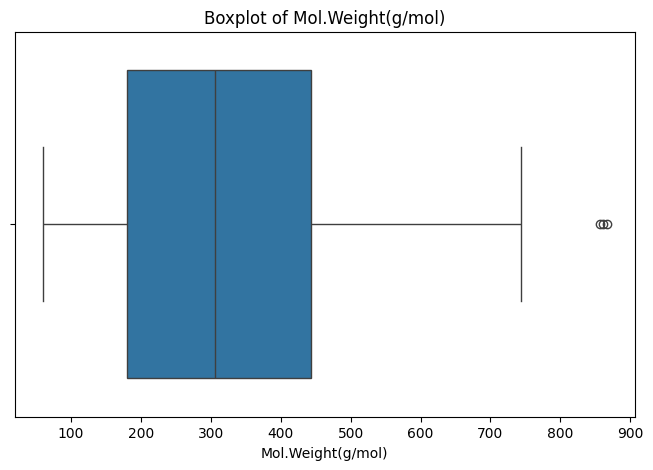

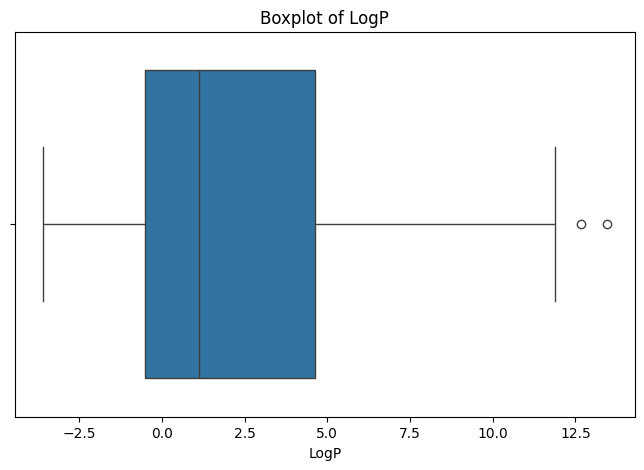

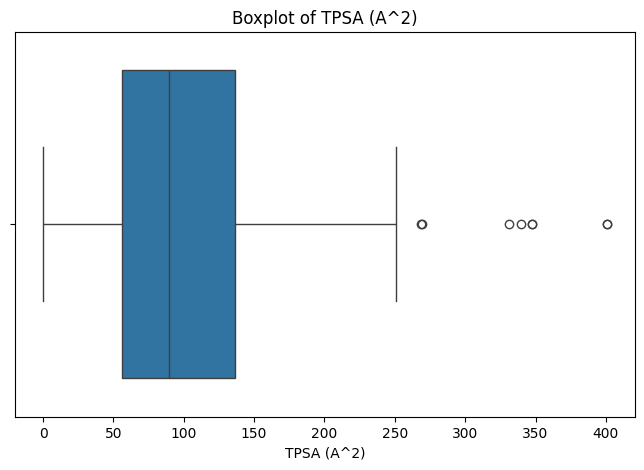

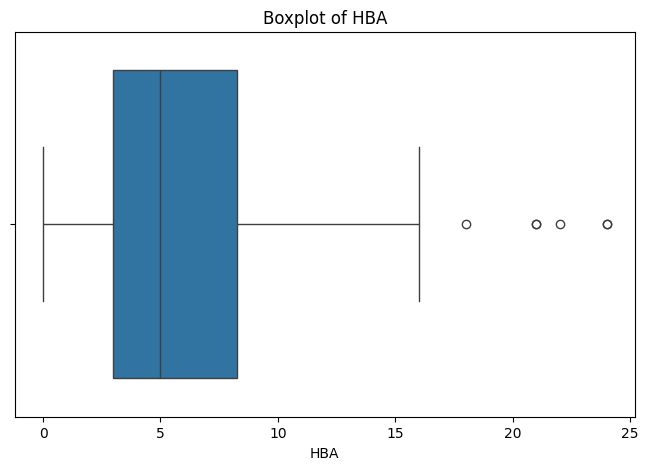

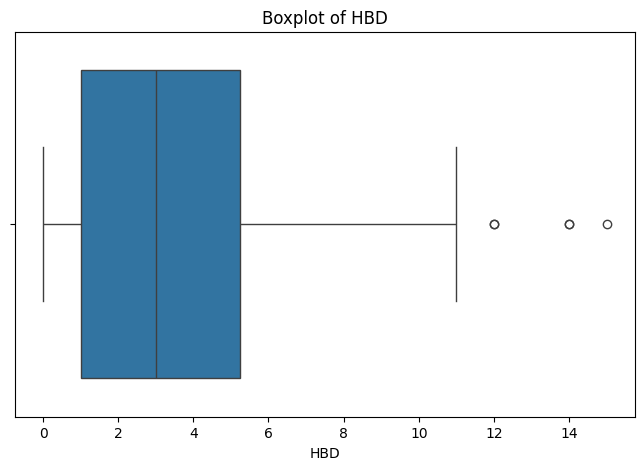

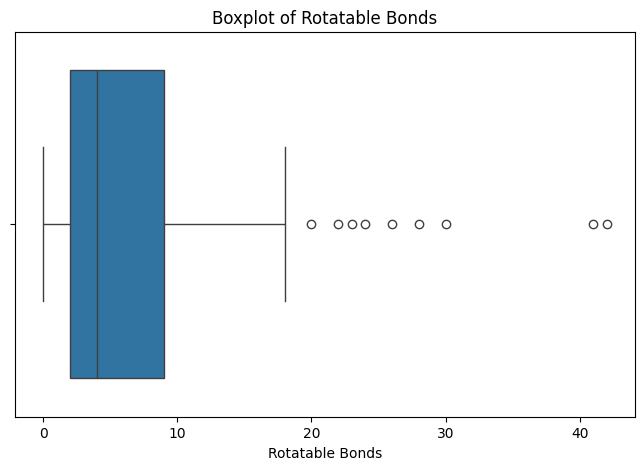

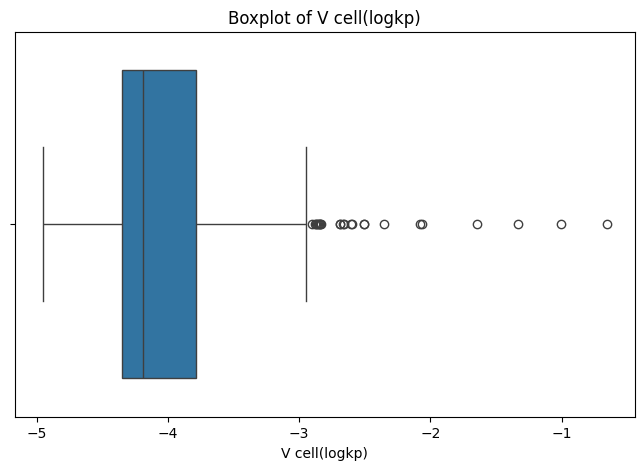

In [ ]:
for col in features:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

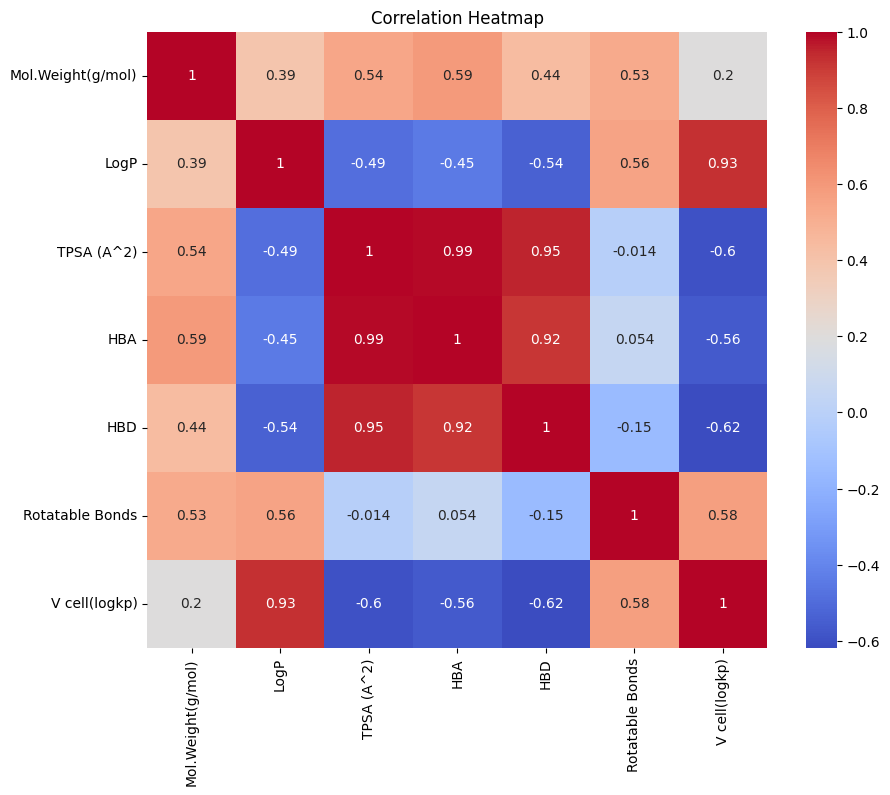

In [ ]:
corr = df[features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

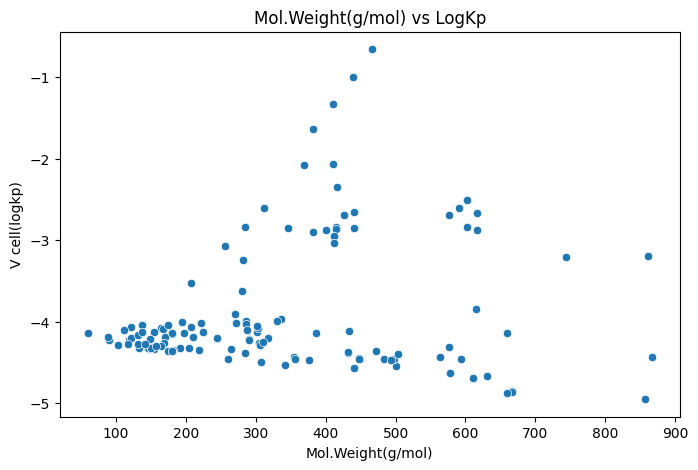

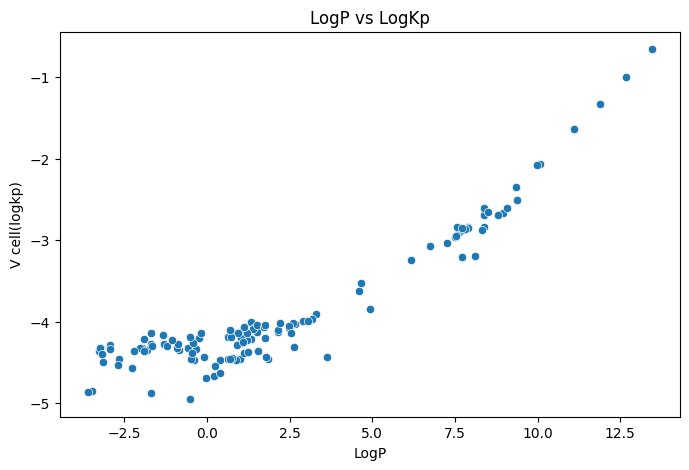

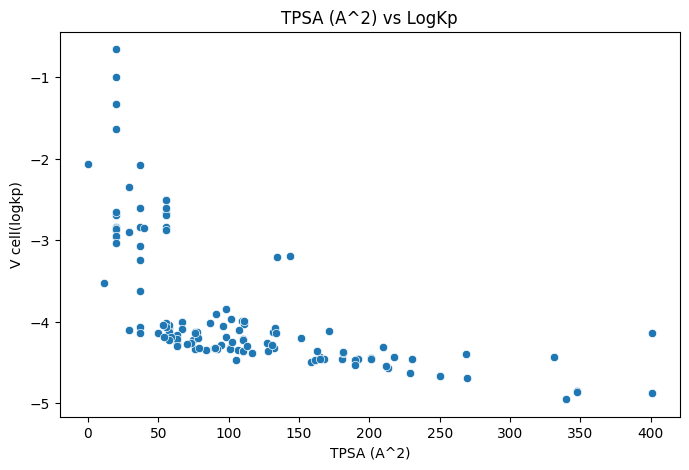

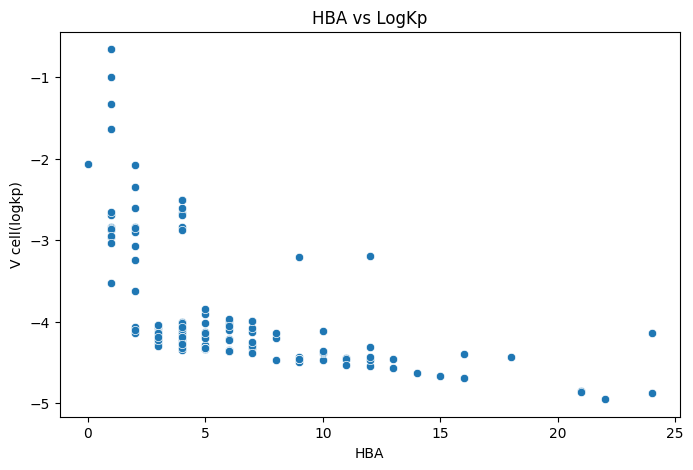

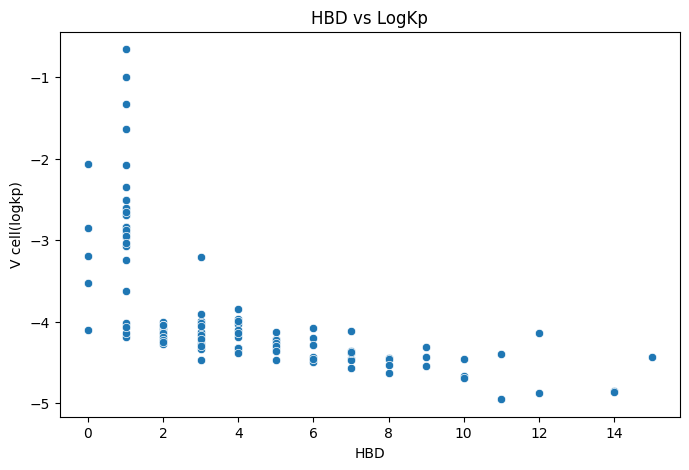

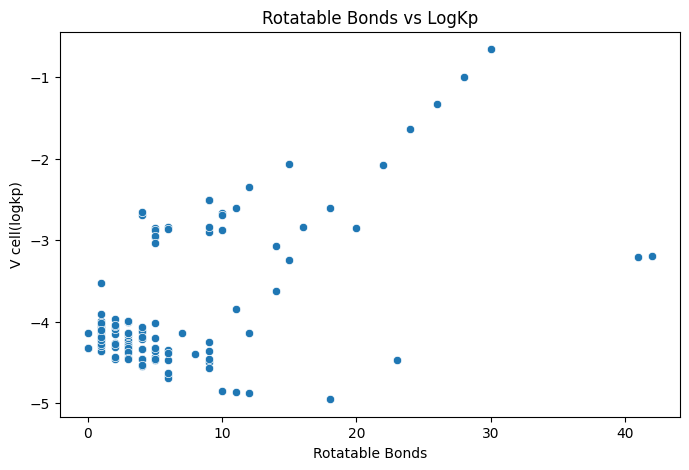

In [ ]:
target = 'V cell(logkp)'

for col in features[:-1]:
    plt.figure()
    sns.scatterplot(x=df[col], y=df[target])
    plt.title(f'{col} vs LogKp')
    plt.show()

In [ ]:
features = [
    'Mol.Weight(g/mol)',
    'LogP',
    'TPSA (A^2)',
    'HBA',
    'HBD',
    'Rotatable Bonds'
]

In [ ]:
target = 'V cell(logkp)'

In [ ]:
ml_df = df[features + [target]]

print(ml_df.head())
print(ml_df.shape)

   Mol.Weight(g/mol)   LogP  TPSA (A^2)  HBA  HBD  Rotatable Bonds  \
0             194.06  1.344       66.76    4    2                3   
1             180.16  1.010       77.76    4    3                2   
2             164.05  1.438       57.53    3    2                2   
3             224.07  1.520       75.99    5    2                4   
4             154.03  1.041       77.76    4    3                1   

   V cell(logkp)  
0      -3.998260  
1      -4.147725  
2      -4.074770  
3      -4.121810  
4      -4.123388  
(132, 7)


In [ ]:
print(ml_df.isnull().sum())

Mol.Weight(g/mol)    0
LogP                 0
TPSA (A^2)           0
HBA                  0
HBD                  0
Rotatable Bonds      0
V cell(logkp)        0
dtype: int64


In [ ]:
X = ml_df[features]
y = ml_df[target]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (105, 6)
Testing set: (27, 6)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Linear Regression Performance
R² Score : 0.9322742941045915
MAE      : 0.19573960593641043
RMSE     : 0.2432820883743165


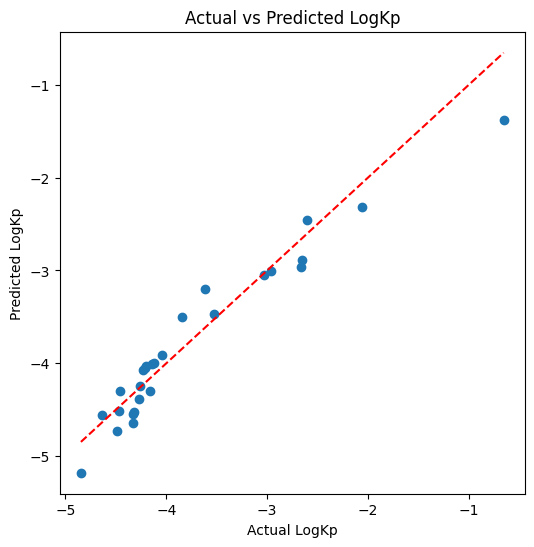

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression Performance")
print("R² Score :", r2)
print("MAE      :", mae)
print("RMSE     :", rmse)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual LogKp")
plt.ylabel("Predicted LogKp")
plt.title("Actual vs Predicted LogKp")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.show()

Random Forest Regression Performance
R² Score : 0.9638584128698442
MAE      : 0.10623784588699986
RMSE     : 0.17772027444366362


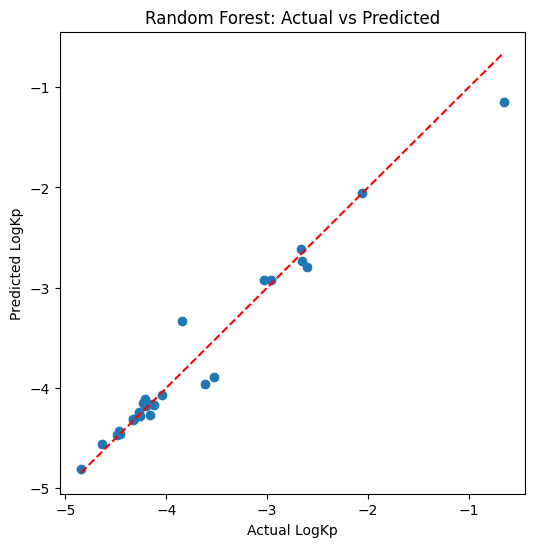

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Regression Performance")
print("R² Score :", r2_rf)
print("MAE      :", mae_rf)
print("RMSE     :", rmse_rf)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual LogKp")
plt.ylabel("Predicted LogKp")
plt.title("Random Forest: Actual vs Predicted")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.show()

SVR Performance
R² Score : 0.9493330982222888
MAE      : 0.11267456094435342
RMSE     : 0.21042412953525136


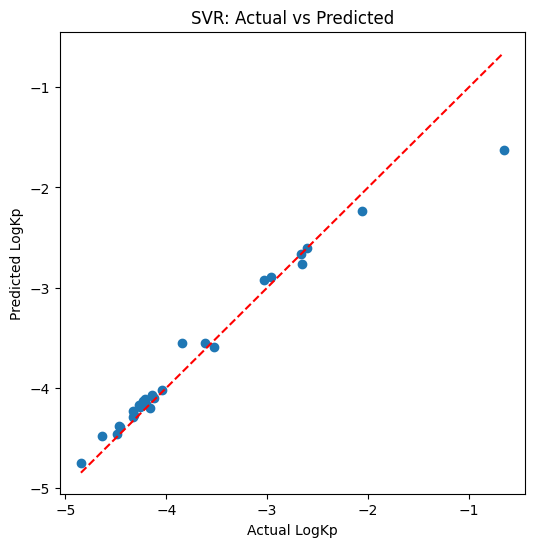

In [ ]:
from sklearn.svm import SVR
svr_model = SVR(
    kernel='rbf'
)
svr_model.fit(X_train_scaled, y_train)

y_pred_svr = svr_model.predict(X_test_scaled)

r2_svr = r2_score(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

print("SVR Performance")
print("R² Score :", r2_svr)
print("MAE      :", mae_svr)
print("RMSE     :", rmse_svr)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_svr)
plt.xlabel("Actual LogKp")
plt.ylabel("Predicted LogKp")
plt.title("SVR: Actual vs Predicted")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest Regression',
        'SVR'
    ],

    'R² Score': [
        r2,
        r2_rf,
        r2_svr
    ],

    'MAE': [
        mae,
        mae_rf,
        mae_svr
    ],

    'RMSE': [
        rmse,
        rmse_rf,
        rmse_svr
    ]
})

print(comparison_df)

                      Model  R² Score       MAE      RMSE
0         Linear Regression  0.932274  0.195740  0.243282
1  Random Forest Regression  0.963858  0.106238  0.177720
2                       SVR  0.949333  0.112675  0.210424


In [ ]:
def classify_permeability(logkp):
    if logkp < -6:
        return 'Low'
    elif logkp < -4:
        return 'Medium'
    else:
        return 'High'
df['Permeability_Class'] = df['V cell(logkp)'].apply(
    classify_permeability
)

print(df['Permeability_Class'].value_counts())

X_class = df[features]
y_class = df['Permeability_Class']

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_class_encoded = label_encoder.fit_transform(y_class)
print(label_encoder.classes_)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class_encoded,
    test_size=0.2,
    random_state=42
)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

Permeability_Class
Medium    92
High      40
Name: count, dtype: int64
['High' 'Medium']


Logistic Regression Accuracy:
1.0

Classification Report:

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        10
      Medium       1.00      1.00      1.00        17

    accuracy                           1.00        27
   macro avg       1.00      1.00      1.00        27
weighted avg       1.00      1.00      1.00        27


Confusion Matrix:

[[10  0]
 [ 0 17]]


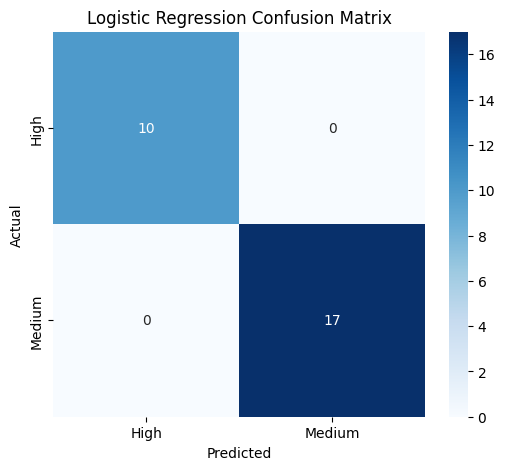

In [ ]:
# Logistic Regression Classification

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

# Train model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(
    X_train_c_scaled,
    y_train_c
)

# Predictions
y_pred_log = log_model.predict(
    X_test_c_scaled
)

# Accuracy
acc_log = accuracy_score(
    y_test_c,
    y_pred_log
)
print("Logistic Regression Accuracy:")
print(acc_log)

# Classification report
print("\nClassification Report:\n")
print(
    classification_report(
        y_test_c,
        y_pred_log,
        target_names=label_encoder.classes_
    )
)

# Confusion matrix
cm_log = confusion_matrix(
    y_test_c,
    y_pred_log
)
print("\nConfusion Matrix:\n")
print(cm_log)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Random Forest Classification Accuracy:
1.0

Classification Report:

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        10
      Medium       1.00      1.00      1.00        17

    accuracy                           1.00        27
   macro avg       1.00      1.00      1.00        27
weighted avg       1.00      1.00      1.00        27


Confusion Matrix:

[[10  0]
 [ 0 17]]


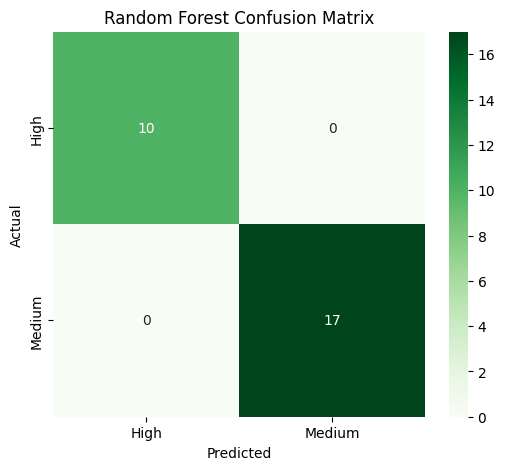

In [ ]:
# Random Forest Classification

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

# Create model
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_classifier.fit(
    X_train_c,
    y_train_c
)

# Predictions
y_pred_rf_class = rf_classifier.predict(
    X_test_c
)

# Accuracy
acc_rf_class = accuracy_score(
    y_test_c,
    y_pred_rf_class
)

print("Random Forest Classification Accuracy:")
print(acc_rf_class)

# Classification report
print("\nClassification Report:\n")

print(
    classification_report(
        y_test_c,
        y_pred_rf_class,
        target_names=label_encoder.classes_
    )
)

# Confusion matrix
cm_rf = confusion_matrix(
    y_test_c,
    y_pred_rf_class
)

print("\nConfusion Matrix:\n")
print(cm_rf)

# Plot confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',

    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
classification_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest Classification'
    ],

    'Accuracy': [
        acc_log,
        acc_rf_class
    ]
})

print(classification_results)

                          Model  Accuracy
0           Logistic Regression       1.0
1  Random Forest Classification       1.0


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(
    rf_model, # Changed from best_rf to rf_model
    X,        # Changed from scaler.transform(X) to X since rf_model was trained on unscaled X_train
    y,
    cv=5,
    scoring='r2'
)

print("\nCross Validation Scores:")
print(cv_scores)

print("Mean CV Score:", np.mean(cv_scores))


Cross Validation Scores:
[0.78671675 0.75675694 0.87628202 0.9682363  0.85475986]
Mean CV Score: 0.8485503738545358
